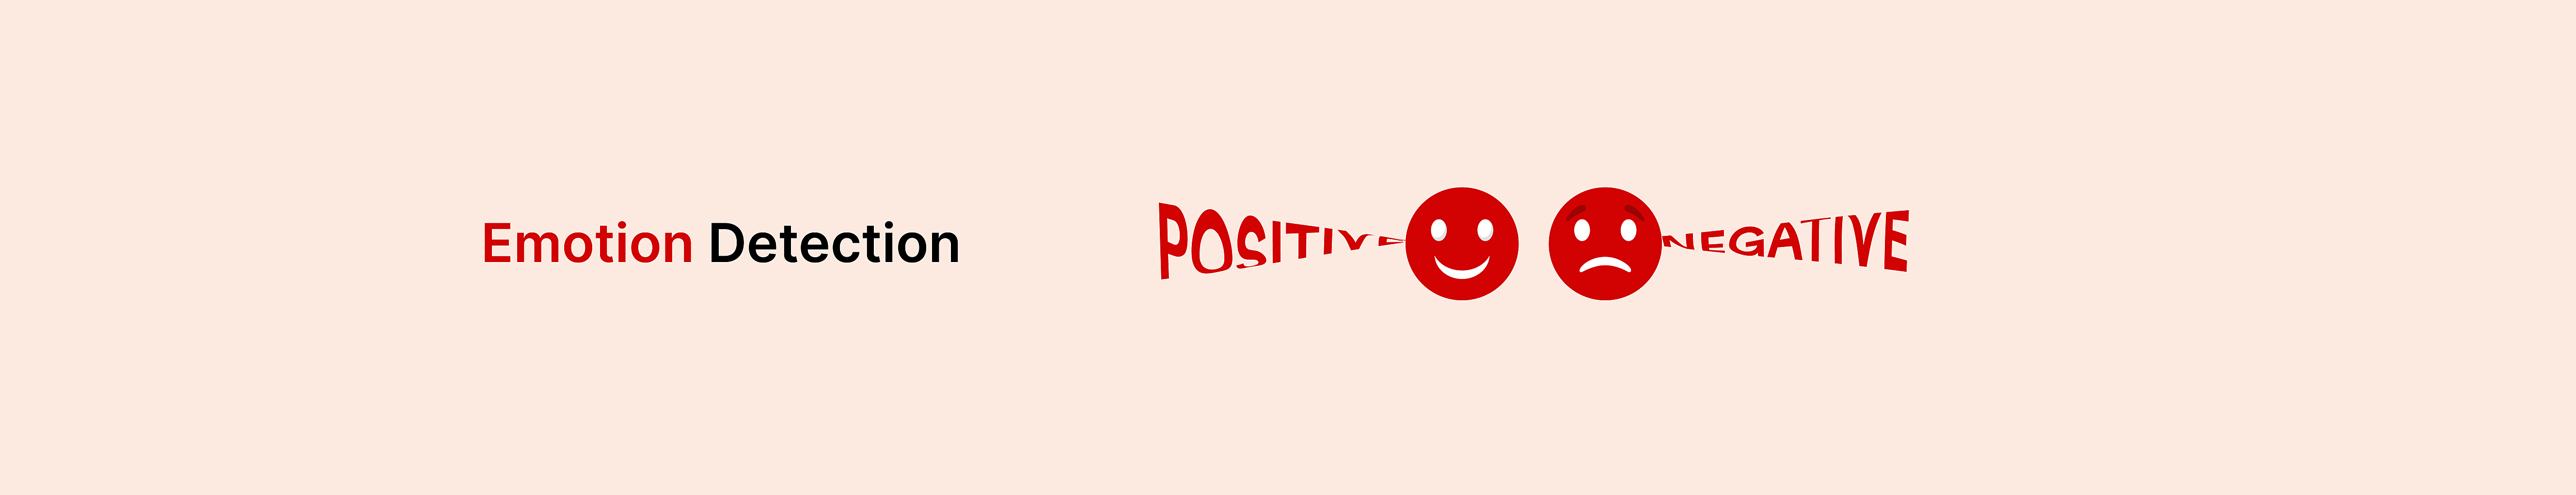

<h2><center>Starter Code for Emotion Detection</center></h2>

<!-- <h6><center>Author : Shubhamai</center></h6> -->



<!-- --- -->



### What we are going to Learn

  - Basics of Natual Language Preprocessing
  - Using a very popular & powerful python library called [spaCy](https://spacy.io/) for language language processing to see how we can preprocess out texts using spaCy and convert them into numbers. 
  - Using Decision Tree Classifier from sklearn to train, validate & test the  model for text classification.
  - Testing and Submitting the Results to the Challenge. 

# Natural Language Preprocessing 🗣️ 

Now Natural Language Preprocessing ( or **NLP** in short ), actually allows Machines to understand human languages and and do certain kind of task such as classification, for ex. 

  - Gmail   -   Classifying emails as Spam/Not Spam. 
  
  - GPT-3 ( A powerful language model by [OpenAI](https://openai.com/) ) -   Generating blogs so good that even humans couldn't classify accuractly if the blog was generated by machine or human 🤯   

and tons of others....


Now in this challange, we are going to learn a very basic task in Natural Language Processing, which is Text Classification, so let's begin!


### Downloading Dataset

AIcrowd had a recent addition that allows you to directly download the dataset from any challenge using AIcrowd CLI. 

So we will first need to download the python library by AIcrowd that will allow us to download the dataset by just inputting the API key. 

In [33]:
!pip install aicrowd-cli

In [34]:
API_KEY = 'cc0a3da7611cfc6098a7bd9db11b3ecf' # Please get your your API Key from [https://www.aicrowd.com/participants/me]
!aicrowd login --api-key $API_KEY

API Key valid
Saved API Key successfully!


In [35]:
# Downloading the Dataset
!mkdir data
!aicrowd dataset download --challenge emotion-detection -j 3 -o data

mkdir: cannot create directory ‘data’: File exists
val.csv: 100% 262k/262k [00:00<00:00, 3.00MB/s]
test.csv: 100% 642k/642k [00:00<00:00, 6.18MB/s]
train.csv: 100% 2.30M/2.30M [00:00<00:00, 12.9MB/s]


### Downloading & Importing Libraries

Here we are going to use spaCy to do our text classification task, now [spaCy](https://spacy.io/) is a very popular python library for Natural Language Processing and got one of the beautiful documentation I have ever seen 😇 and they also got the [Advance NLP with spaCy](https://course.spacy.io/en/) if anyone want's to check out, but back on the topic.   

We are also downloading a python file `explacy.py` from [tylerneylon/explacy](https://github.com/tylerneylon/explacy) which will help us in  visualizing some topics of NLP 

In [36]:
!pip install --upgrade vaderSentiment

Requirement already up-to-date: vaderSentiment in /usr/local/lib/python3.7/dist-packages (3.3.2)


In [38]:
import os
import time
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import f1_score, accuracy_score

### Reading Dataset

Reading the necessary files to train, validation & submit our results! 

In [39]:
train_dataset = pd.read_csv("data/train.csv")
validation_dataset = pd.read_csv("data/val.csv")[1:]
test_dataset = pd.read_csv("data/test.csv")
train_dataset

,text,label
0,takes no time to copy/paste a press release,0
1,You're delusional,1
2,Jazz fan here. I completely feel. Lindsay Mann...,0
3,ah i was also confused but i think they mean f...,0
4,Thank you so much. ♥️ that means a lot.,0
...,...,...
31250,thank you so much! :),0
31251,That works too. To each their own.,0
31252,"Friendly fire dude, I wanted the other criminal",0
31253,"Yes, exactly. Fix a date and if he still procr...",0


# Text Classification  🧠

In [40]:
analyzer = SentimentIntensityAnalyzer()
for sentence in train_dataset['text'][:20]:
    vs = analyzer.polarity_scores(sentence)
    print("{:-<65} {}".format(sentence, str(vs)))

takes no time to copy/paste a press release---------------------- {'neg': 0.239, 'neu': 0.761, 'pos': 0.0, 'compound': -0.296}
You're delusional------------------------------------------------ {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Jazz fan here. I completely feel. Lindsay Mann cousins has more votes than Lindsay Mann, and Lindsay Mann hasn't even stepped on the court this year {'neg': 0.0, 'neu': 0.916, 'pos': 0.084, 'compound': 0.3182}
ah i was also confused but i think they mean friends around the same age {'neg': 0.088, 'neu': 0.691, 'pos': 0.221, 'compound': 0.5423}
Thank you so much. ♥️ that means a lot.-------------------------- {'neg': 0.0, 'neu': 0.534, 'pos': 0.466, 'compound': 0.7893}
And I’ll be there!!!--------------------------------------------- {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
There are some amazingly cringey compilations of terrible dialogue from this show on yt {'neg': 0.193, 'neu': 0.807, 'pos': 0.0, 'compound': -0.4767}
Check the 

## Training data

In [41]:
start_time = time.time()
train_dataset['compound'] = train_dataset['text'].apply(
    lambda text: analyzer.polarity_scores(text).get('compound')
)
train_dataset['pred'] = train_dataset['compound'].apply(
    lambda score: 1 if score <= -0.05 else 0
)
print("Elapsed time: %s seconds" % round(time.time() - start_time, 4))

train_dataset.head(20)

Elapsed time: 3.2951 seconds


,text,label,compound,pred
0,takes no time to copy/paste a press release,0,-0.2960,1
1,You're delusional,1,0.0000,0
2,Jazz fan here. I completely feel. Lindsay Mann...,0,0.3182,0
3,ah i was also confused but i think they mean f...,0,0.5423,0
4,Thank you so much. ♥️ that means a lot.,0,0.7893,0
5,And I’ll be there!!!,0,0.0000,0
6,There are some amazingly cringey compilations ...,0,-0.4767,1
7,Check the frame (FPS) limit option in the adva...,0,0.2500,0
8,you made me think I was in the dbd subreddit w...,0,-0.1027,1
9,It was in your op.,0,0.0000,0


In [42]:
# Getting F1 & Accuracy score of validation predictions
f1 = f1_score(train_dataset['label'], train_dataset['pred'])
accuracy = accuracy_score(train_dataset['label'], train_dataset['pred'])

print(f"Validation F1 Score  : {round(f1, 4)} and Accuracy Score {round(accuracy, 4)}")

Validation F1 Score  : 0.5426 and Accuracy Score 0.7711


## Validation data  

In [43]:
validation_dataset['compound'] = validation_dataset['text'].apply(
    lambda text: analyzer.polarity_scores(text).get('compound')
)
validation_dataset['pred'] = validation_dataset['compound'].apply(
    lambda score: 1 if score <= -0.05 else 0
)
# Getting F1 & Accuracy score of validation predictions
f1 = f1_score(validation_dataset['label'], validation_dataset['pred'])
accuracy = accuracy_score(validation_dataset['label'], validation_dataset['pred'])

print(f"Validation F1 Score  : {round(f1, 4)} and Accuracy Score {round(accuracy, 4)}")

Validation F1 Score  : 0.5414 and Accuracy Score 0.7702


# Submitting Results 📄

In [44]:
test_dataset['compound'] = test_dataset['text'].apply(
    lambda text: analyzer.polarity_scores(text).get('compound')
)
test_dataset['label'] = test_dataset['compound'].apply(
    lambda score: 1 if score <= -0.05 else 0
)
test_dataset.drop(columns=['compound'], inplace=True)

test_dataset.head(20)

,text,label
0,I was already over the edge with Cassie Zamora...,1
1,I think you're right. She has oodles of cash a...,0
2,Haha I love this. I used to give mine phone bo...,0
3,Probably out of desperation as they going no a...,1
4,Sorry !! You’re real good at that!!,0
5,I say we get the pitch forks and make him have...,0
6,He looks really different now.,0
7,I swear people just want to be angry,1
8,lol robot car,0
9,Yeah I’ve been watching these videos and they ...,0



**Note : Please make sure that there should be filename `submission.csv` in `assets` folder before submitting it**

In [45]:
!mkdir assets

# Saving the sample submission in assets directory
test_dataset.to_csv(os.path.join("assets", "submission.csv"), index=False)

mkdir: cannot create directory ‘assets’: File exists


## Uploading the Results 
**Note : Please save the notebook before submitting it (Ctrl + S)**

In [ ]:
! ls '/content/drive/MyDrive/Colab Notebooks/'

' 5.0-fastai-classifier.ipynb'	'Text Classification'   Untitled0.ipynb


In [46]:
!aicrowd notebook submit -c emotion-detection -a assets --no-verify

Using notebook: /content/drive/MyDrive/Colab Notebooks/Text_Classification.ipynb for submission...
Removing existing files from submission directory...
Scrubbing API keys from the notebook...
submission.zip ━━━━━━━━━━━━━━━━━━━━ 100.0% • 967.7/966.1 KB • 1.1 MB/s • 0:00:00
                                                  ╭─────────────────────────╮                                                  
                                                  │ Successfully submitted! │                                                  
                                                  ╰─────────────────────────╯                                                  
                                                        Important links                                                        
┌──────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  This submission │ https://www.aicrowd.com/challenges/ai-blitz-9/problems/emotion-det

Congratulations 🎉 you did it, but there still a lot of improvement that can be made, data exploration is one of the most import pipelines in machine learning, especially in competitions, so maybe see if there is data imbalance, how minimize it's effects, maybe looking first few rows to each dataset. Or maybe improving the score, have fun!

And btw -

> Don't be shy to ask question related to any errors you are getting or doubts in any part of this notebook in [discussion forum](https://www.aicrowd.com/challenges/ai-blitz-9/problems/emotion-detection/discussion) or in [AIcrowd Discord sever](https://discord.gg/T6uZSWBMSZ), AIcrew will be happy to help you :)

Also, wanna give us your valuable feedback for next blitz or wanna work with us creating blitz challanges ? Let us know! 